# Georgia Election Analysis

## Import Libraries

In [1]:
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("senate.csv")
pedersen_data = pd.read_csv("georgia_pedersen_index.csv")

## Historical data results from the 2022 Georgia Senate Race: Democrat, Republican, and Third Party

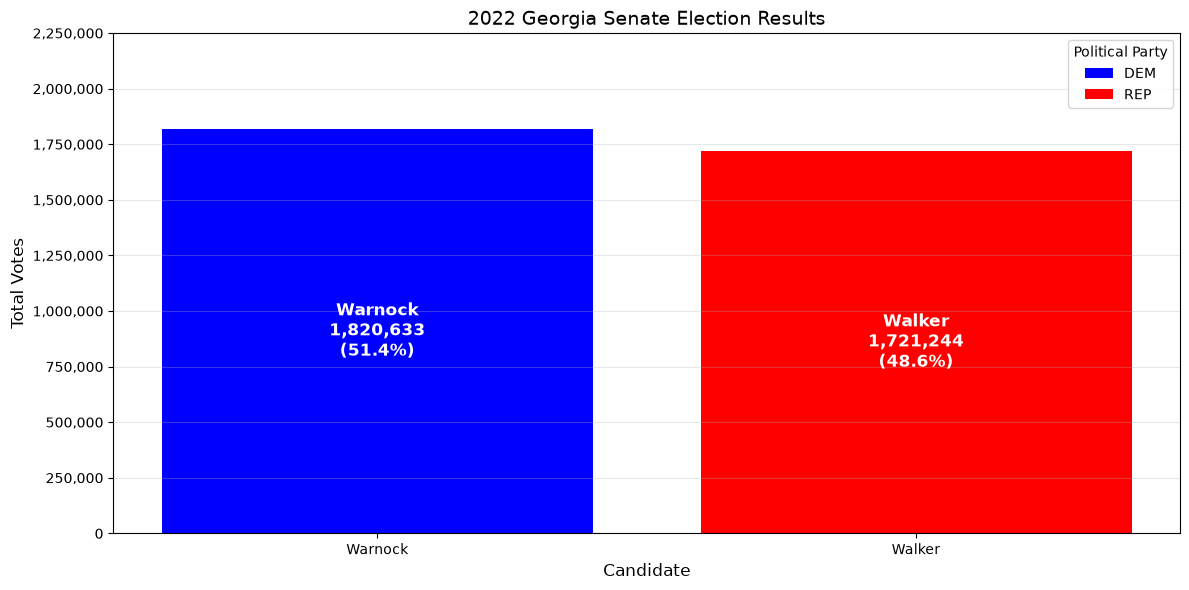

In [2]:
# Use the following data for 2022 election results
dem_results = 1820633
rep_results = 1721244
third_party_results = 0
historical_dem_percentage = (
    dem_results / (dem_results + rep_results + third_party_results)
) * 100
historical_rep_percentage = (
    rep_results / (dem_results + rep_results + third_party_results)
) * 100
historical_third_party_percentage = (
    third_party_results / (dem_results + rep_results + third_party_results)
) * 100
data_2024 = pd.DataFrame(
    [
        {
            "Answer": "Warnock",
            "Political Party": "DEM",
            "Results": dem_results,
            "Percentage": historical_dem_percentage,
        },
        {
            "Answer": "Walker",
            "Political Party": "REP",
            "Results": rep_results,
            "Percentage": historical_rep_percentage,
        },
        {
            "Answer": "Third Party",
            "Political Party": "NONE",
            "Results": third_party_results,
            "Percentage": historical_third_party_percentage,
        },
    ]
)

# Sort by sample size (largest first)
data_2024 = data_2024.sort_values("Results", ascending=False)

# Clean index
data_2024.index = range(1, len(data_2024) + 1)
data_2024 = data_2024.head(3)

# Reassign the 'NONE' party to 'THIRD' as 'Third Party' for better clarity in the graph
alias_map = {"NONE": "THIRD"}

# Define colors for each party
party_colors = {"DEM": "blue", "REP": "red", "NONE": "green"}

# Define colors for each party in the graph's legend
legend_elements = [
    Patch(facecolor="blue", label="DEM"),
    Patch(facecolor="red", label="REP"),
]

# Create bar chart
plt.figure(figsize=(12, 6))

# Create bars with party colors
for candidate in data_2024["Answer"]:
    # Georgia has a unique case with a run-off election, so we will not include the "Third Party" candidate in the bar chart.
    if candidate != "Third Party":
        # Get the party for this candidate
        display_name = alias_map.get(candidate, candidate)
        party = data_2024[data_2024["Answer"] == candidate]["Political Party"].iloc[0]
        color = party_colors.get(party, "gray")

        # Get the results (votes)
        results = data_2024[data_2024["Answer"] == candidate]["Results"].iloc[0]

        # Create the bar
        plt.bar(display_name, results, color=color)

    else:
        continue

# Add value labels INSIDE the bars (candidate name, votes, percentage)
for i, (candidate, results, percentage) in enumerate(
    zip(data_2024["Answer"], data_2024["Results"], data_2024["Percentage"])
):
    # Format votes with commas
    votes_formatted = f"{results:,}"

    # Conditionally build the label text
    if candidate != "Third Party":
        # Show candidate, votes, and percentage for others
        label_text = f"{candidate}\n{votes_formatted}\n({percentage:.1f}%)"
    else:
        continue

    # Place text inside the bar (centered, with some offset from bottom)
    plt.text(
        i,
        results / 2,  # Position at half the bar height
        label_text,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white",
    )  # White text for contrast

plt.xlabel("Candidate", fontsize=12)
plt.ylabel("Total Votes", fontsize=12)
plt.title("2022 Georgia Senate Election Results", fontsize=14)

# Format y-axis to show numbers with commas
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(axis="y", alpha=0.3)

# Set y-axis limit to ensure bars are fully visible
plt.ylim(0, 2250000)

# Add legend
plt.legend(handles=legend_elements, title="Political Party", loc="upper right")

plt.tight_layout()
plt.show()

## Data Results of Current Week's Polls, by Candidate

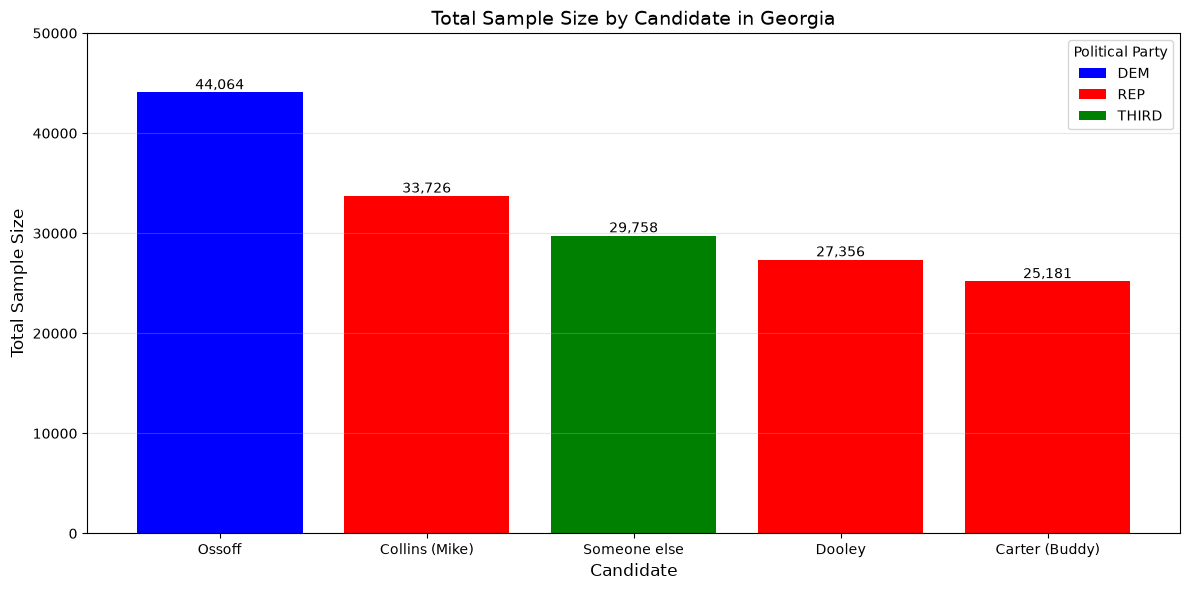

In [3]:
# Construct dataset by polling data sample size

# Rename columns
data = data.rename(
    columns={
        "state": "State",
        "sample_size": "Sample Size",
        "party": "Political Party",
        "answer": "Answer",
    }
)

# Filter: Georgia AND (DEM or REP or NONE)
data = data[
    (data["State"] == "GA") & (data["Political Party"].isin(["DEM", "REP", "NONE"]))
]

# Remove unwanted answers, data that is not useful for analysis
unwanted = ["Don't know", "Refused", "No opinion"]
data = data[~data["Answer"].isin(unwanted)]

# Remove duplicates
data = data.drop_duplicates()

# Group by Answer and Political Party, summing Sample Size
df_aggregated = (
    data.groupby(["Answer", "Political Party"])["Sample Size"].sum().reset_index()
)
df_aggregated = df_aggregated.sort_values("Sample Size", ascending=False)

# Sort by sample size (largest first)
df_aggregated = df_aggregated.sort_values("Sample Size", ascending=False)

# Clean index
df_aggregated.index = range(1, len(df_aggregated) + 1)
df_aggregated = df_aggregated.head(5)

# Reassign the 'NONE' party to 'THIRD' as 'Third Party' for better clarity in the graph
alias_map = {
    "NONE": "THIRD",
}

# Define colors for each party
party_colors = {"DEM": "blue", "REP": "red", "NONE": "green"}

# Define colors for each party in the graph's legend
legend_elements = [
    Patch(facecolor="blue", label="DEM"),
    Patch(facecolor="red", label="REP"),
    Patch(facecolor="green", label=alias_map.get("NONE", "THIRD")),
]

# Create bart chart
plt.figure(figsize=(12, 6))

# Create bars with party colors
for candidate in df_aggregated["Answer"]:
    # Assign color and answer based on the candidate's political party
    display_name = alias_map.get(candidate, candidate)
    party = df_aggregated[df_aggregated["Answer"] == candidate]["Political Party"].iloc[
        0
    ]
    color = party_colors.get(party, "gray")

    # Get the sample size
    sample_size = df_aggregated[df_aggregated["Answer"] == candidate][
        "Sample Size"
    ].iloc[0]

    # Finalize the bar chart with the candidate's name, sample size, and color
    plt.bar(
        display_name,
        sample_size,
        color=color,
        label=party if candidate == df_aggregated["Answer"].iloc[0] else "",
    )

# Add value labels
for i, (candidate, sample_size) in enumerate(
    zip(df_aggregated["Answer"], df_aggregated["Sample Size"])
):
    plt.text(
        i, sample_size, f"{int(sample_size):,}", ha="center", va="bottom", fontsize=10
    )

# Set y-axis limit to ensure bars are fully visible
plt.ylim(0, 50000)

plt.xlabel("Candidate", fontsize=12)
plt.ylabel("Total Sample Size", fontsize=12)
plt.title("Total Sample Size by Candidate in Georgia", fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title="Political Party", loc="upper right")

plt.tight_layout()
plt.show()

## Data Results of Week's Polls, by Political Party

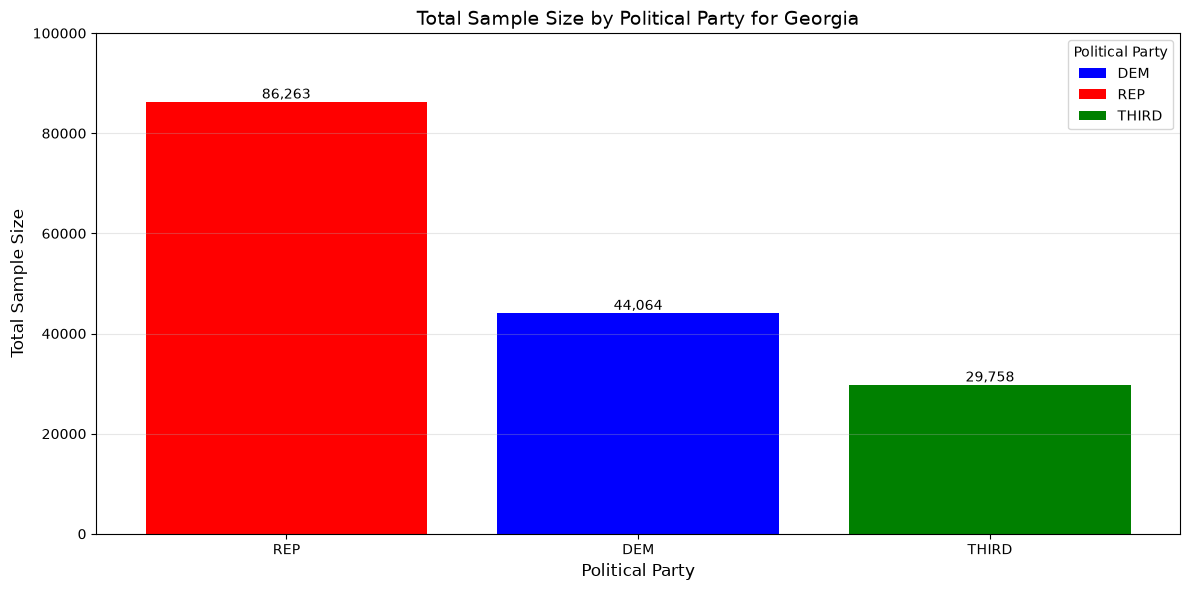

In [4]:
# Combine results if they are in the same Party
party_totals = (
    df_aggregated.groupby("Political Party")["Sample Size"].sum().reset_index()
)

# Sort by sample size (largest first)
party_totals = party_totals.sort_values("Sample Size", ascending=False)

# Variable to hold the total sample size for the Democratic party
dem_total = party_totals.loc[
    party_totals["Political Party"] == "DEM", "Sample Size"
].iloc[0]

# Variable to hold the total sample size for the Republican party
rep_total = party_totals.loc[
    party_totals["Political Party"] == "REP", "Sample Size"
].iloc[0]

# Variable to hold the total sample size for third party candidates
third_party_total = party_totals.loc[
    party_totals["Political Party"] == "NONE", "Sample Size"
].iloc[0]

# Clean index
party_totals.index = range(1, len(party_totals) + 1)
party_totals = party_totals.head(3)

# Reassign the 'NONE' party to 'THIRD' as 'Third Party' for better clarity in the graph
alias_map = {"NONE": "THIRD"}

# Define colors for each party
party_colors = {"DEM": "blue", "REP": "red", "NONE": "green"}

# Define colors for each party in the graph's legend
legend_elements = [
    Patch(facecolor="blue", label="DEM"),
    Patch(facecolor="red", label="REP"),
    Patch(facecolor="green", label=alias_map.get("NONE", "THIRD")),
]

# Create bart chart
plt.figure(figsize=(12, 6))

# Create bars with party colors
for party in party_totals["Political Party"]:
    # Assign color
    color = party_colors.get(party, "gray")

    # Get the sample size
    sample_size = party_totals[party_totals["Political Party"] == party][
        "Sample Size"
    ].iloc[0]

    # Finalize the bar chart with the party's name, sample size, and color
    plt.bar(alias_map.get(party, party), sample_size, color=color)

# Add value labels
for i, (party, sample_size) in enumerate(
    zip(party_totals["Political Party"], party_totals["Sample Size"])
):
    plt.text(
        i, sample_size, f"{int(sample_size):,}", ha="center", va="bottom", fontsize=10
    )

# Set y-axis limit to ensure bars are fully visible
plt.ylim(0, 100000)

plt.xlabel("Political Party", fontsize=12)
plt.ylabel("Total Sample Size", fontsize=12)
plt.title("Total Sample Size by Political Party for Georgia", fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title="Political Party", loc="upper right")

plt.tight_layout()
plt.show()

## Consolidated data from historical results, polling data, and volatility index

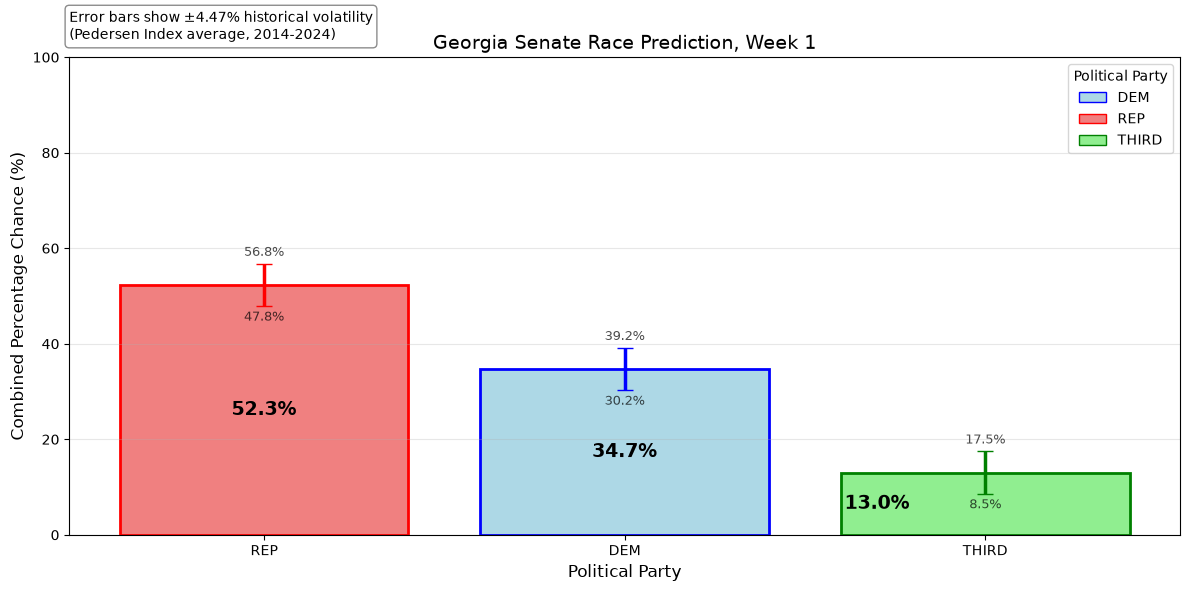

In [5]:
# Update Week **MANUALLY**
week = 1

# Retrieve the Pedersen Index value from the CSV file
pedersen_index_value = pedersen_data.iloc[3, 5]

# Combine the total sample sizes for both parties to get the consolidated data
consolidated_data = dem_total + rep_total + third_party_total

# Calculate the percentage of the total sample size for each party
consolidated_sample_size_dem_percentage = (dem_total / consolidated_data) * 100
consolidated_sample_size_rep_percentage = (rep_total / consolidated_data) * 100
if "NONE" in party_totals["Political Party"].values:
    consolidated_sample_size_third_party_percentage = (
        third_party_total / consolidated_data
    ) * 100

# Calculate the percentage from the 2024 election results for each party and compare
# it to the consolidated sample size percentages
# Include a weighted average of the consolidated sample size percentages and the historical election results percentages
dem_percentage_chance = (consolidated_sample_size_dem_percentage * 0.70) + (
    historical_dem_percentage * 0.30
)
rep_percentage_chance = (consolidated_sample_size_rep_percentage * 0.70) + (
    historical_rep_percentage * 0.30
)
third_party_percentage_chance = (
    consolidated_sample_size_third_party_percentage * 0.70
) + (historical_third_party_percentage * 0.30)

# Create new DataFrame to hold the combined percentages for each party
combined_df = pd.DataFrame(
    {
        "Political Party": ["DEM", "REP", "NONE"],
        "Combined Percentage": [
            dem_percentage_chance,
            rep_percentage_chance,
            third_party_percentage_chance,
        ],
    }
)

# Sort by percentage
combined_df = combined_df.sort_values("Combined Percentage", ascending=False)

# Clean index
combined_df.index = range(1, len(combined_df) + 1)

# Reassign the 'NONE' party to 'THIRD' as 'Third Party' for better clarity in the graph
alias_map = {"NONE": "THIRD"}

# Define colors for each party (lighter versions)
party_colors = {"DEM": "lightblue", "REP": "lightcoral", "NONE": "lightgreen"}
party_edge_colors = {"DEM": "blue", "REP": "red", "NONE": "green"}

# Legend elements
legend_elements = [
    Patch(facecolor="lightblue", edgecolor="blue", label="DEM"),
    Patch(facecolor="lightcoral", edgecolor="red", label="REP"),
    Patch(
        facecolor="lightgreen", edgecolor="green", label=alias_map.get("NONE", "THIRD")
    ),
]

# Create the bar chart
plt.figure(figsize=(12, 6))

# Get data
parties = combined_df["Political Party"].tolist()
percentages = combined_df["Combined Percentage"].tolist()

# Create bars with lighter colors and error bars
bars = []
for i, party in enumerate(parties):
    color = party_colors.get(party, "lightgray")
    edge_color = party_edge_colors.get(party, "gray")
    percentage = percentages[i]

    # Create bar with lighter fill and darker edge
    bar = plt.bar(
        i,
        percentage,
        color=color,
        edgecolor=edge_color,
        linewidth=2,
        yerr=pedersen_index_value,
        capsize=6,
        error_kw={"linewidth": 2.5, "ecolor": edge_color, "capsize": 6},
    )
    bars.append(bar)

# Add value labels INSIDE the bars (showing the percentage)
for i, (party, percentage) in enumerate(zip(parties, percentages)):
    label = f"{percentage:.1f}%"
    if "NONE" in party:
        plt.text(
            i - 0.3,
            percentage / 2,
            label,
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black",
        )
    else:
        plt.text(
            i,
            percentage / 2,
            label,
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black",
        )

# Add range labels at the top of error bars
for i, percentage in enumerate(percentages):
    upper = percentage + pedersen_index_value
    lower = percentage - pedersen_index_value
    plt.text(
        i,
        upper + 1,
        f"{upper:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
        alpha=0.7,
    )
    plt.text(
        i,
        lower - 1,
        f"{lower:.1f}%",
        ha="center",
        va="top",
        fontsize=9,
        color="black",
        alpha=0.7,
    )

# Set y-axis limits (0 to 100 since it's a percentage)
plt.ylim(0, 100)

# Labels and title
plt.xlabel("Political Party", fontsize=12)
plt.ylabel("Combined Percentage Chance (%)", fontsize=12)
plt.title(f"Georgia Senate Race Prediction, Week {week}", fontsize=14)

# Apply aliases to x-axis tick labels
x_labels = [alias_map.get(party, party) for party in parties]
plt.xticks(range(len(parties)), x_labels)

# Add grid
plt.grid(axis="y", alpha=0.3)

# Add legend
plt.legend(handles=legend_elements, title="Political Party", loc="upper right")

# Add annotation explaining error bars
plt.text(
    0,
    1.1,
    f"Error bars show ±{pedersen_index_value:.2f}% historical volatility\n(Pedersen Index average, 2014-2024)",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"),
)

plt.tight_layout()
plt.savefig(
    f"_static/images/georgia_graph_week_{week}.png", dpi=300, bbox_inches="tight"
)
plt.show()